# Segmenting Charging Sessions into Archetypes

Module D of the platform. The original brief asked for *user* segmentation, but this
dataset has exactly one session per user, so there is no per-user history to aggregate.
We segment the **sessions** instead: group them by how the charge actually behaved —
energy delivered, duration, distance since last charge, SOC swing, charging rate and
cost — and give each group a short, human-readable name.

> **Clustering**
>
> Clustering is unsupervised learning: there is no label to predict. The algorithm
> partitions rows into groups so that rows in the same group are more similar to each
> other than to rows in other groups. It is descriptive — it tells you what structure is
> already there.

> **K-Means**
>
> K-Means picks `k` cluster centres, assigns every point to its nearest centre, moves
> each centre to the mean of its assigned points, and repeats until nothing moves. It
> minimises the total squared distance from points to their centre (the *inertia*).
> Because it works in Euclidean distance, features must be standardised first or the
> largest-magnitude column dominates.

## Contents

* Load the processed sessions
* Choose the behavioural feature subset
* Standardise the features
* Choose `k` with the elbow and the silhouette
* Fit K-Means and profile the clusters
* Name the archetypes
* Visualise the clusters
* What the low silhouette means
* Persist the segmenter

## Load the processed sessions

In [1]:
import sys

sys.path.insert(0, "../src")

import numpy as np
import pandas as pd

from evcharging.config import CLEAN_PARQUET

df = pd.read_parquet(CLEAN_PARQUET)
df.shape

(1320, 57)

## Choose the behavioural feature subset

We cluster on six columns that describe *how a session ran*, not *who ran it*:

* `energy_kwh` — energy delivered
* `duration_hours` — true session length
* `distance_km` — distance driven since the last charge
* `soc_delta_pct` — percentage points of battery added
* `charging_rate_kw` — average power
* `cost_usd` — session cost

Vehicle model, location and user type are deliberately excluded — we want archetypes of
behaviour that any driver could fall into, not a re-discovery of the categorical labels.

About 190 sessions are missing `energy_kwh`, `charging_rate_kw` or `distance_km`. Per the
Phase-1 policy they are median-imputed (not dropped) so every session still receives a
cluster label for the dashboard. That imputation slightly inflates the centre of the
distribution and is noted again in the conclusion.

In [2]:
from evcharging.models.segmentation import CLUSTER_FEATURES, prepare_matrix

CLUSTER_FEATURES

['energy_kwh',
 'duration_hours',
 'distance_km',
 'soc_delta_pct',
 'charging_rate_kw',
 'cost_usd']

In [3]:
X = prepare_matrix(df)
assert X.isna().sum().sum() == 0
X.describe().round(2)

,energy_kwh,duration_hours,distance_km,soc_delta_pct,charging_rate_kw,cost_usd
count,1320.00,1320.00,1320.00,1320.00,1320.00,1320.00
mean,42.65,2.23,153.53,26.01,25.95,22.55
std,21.84,1.01,83.83,29.81,13.66,10.75
min,0.05,0.50,0.86,-84.36,1.47,0.23
25%,24.87,1.38,81.93,4.81,14.43,13.37
50%,42.69,2.18,152.26,25.00,25.60,22.08
75%,60.55,3.08,221.96,47.72,36.96,31.65
max,152.24,3.98,398.36,127.46,97.34,69.41


## Standardise the features

> **Standardisation**
>
> Standardising a feature subtracts its mean and divides by its standard deviation, so
> every feature has mean 0 and standard deviation 1. K-Means uses straight-line distance,
> so without this a column measured in the thousands (there are none here, but `cost_usd`
> and `distance_km` differ by 10×) would count far more than one measured in single
> digits.

`prepare_matrix` returns the raw feature frame; the scaling happens inside the pipeline
(`StandardScaler` → `KMeans`). We show the scaled values here so the `k` search below is
transparent.

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pd.DataFrame(X_scaled, columns=X.columns).describe().round(2).loc[["mean", "std"]]

,energy_kwh,duration_hours,distance_km,soc_delta_pct,charging_rate_kw,cost_usd
mean,0.0,-0.0,-0.0,-0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0


## Choose `k` with the elbow and the silhouette

Two standard diagnostics, computed for `k` = 2…8:

* **Inertia / elbow** — inertia always falls as `k` rises (more centres fit the data
  tighter). We look for the "elbow" where the rate of improvement drops sharply; adding
  clusters past the elbow buys little.
* **Silhouette score** — for each point, `(b − a) / max(a, b)` where `a` is the mean
  distance to its own cluster and `b` the mean distance to the nearest other cluster.
  It ranges from −1 to 1; values near 0 mean clusters overlap, near 1 mean they are
  cleanly separated. We report the average over all points.

In [5]:
from evcharging.models.segmentation import search_k

search = search_k(X, k_values=range(2, 9))
search.as_frame().round(4)

,inertia,silhouette
k,,
2,6923.8632,0.1259
3,6280.2795,0.1165
4,5830.1477,0.1152
5,5410.5482,0.1225
6,5076.0382,0.1256
7,4796.7225,0.1254
8,4567.7372,0.1286


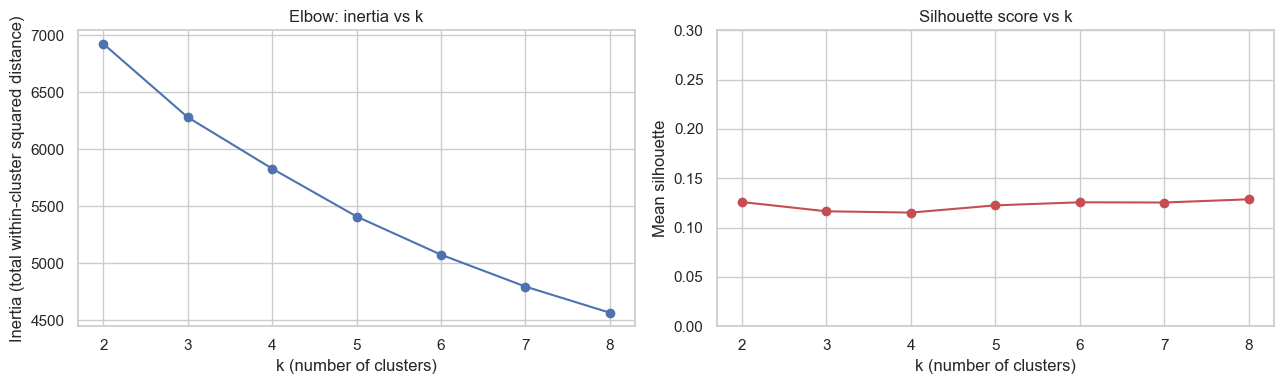

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
frame = search.as_frame()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(frame.index, frame["inertia"], marker="o")
axes[0].set_title("Elbow: inertia vs k")
axes[0].set_xlabel("k (number of clusters)")
axes[0].set_ylabel("Inertia (total within-cluster squared distance)")

axes[1].plot(frame.index, frame["silhouette"], marker="o", color="#C44E52")
axes[1].set_title("Silhouette score vs k")
axes[1].set_xlabel("k (number of clusters)")
axes[1].set_ylabel("Mean silhouette")
axes[1].set_ylim(0, 0.3)

plt.tight_layout()
plt.show()

**Observations**

* The inertia curve is smooth with only a gentle bend around `k` = 3–4 — no sharp elbow.
* The silhouette score stays between about 0.11 and 0.13 for **every** `k`. There is no
  value of `k` that produces well-separated clusters.
* When the silhouette is this flat, the sensible choice is the smallest `k` that still
  gives a useful description. `choose_k` encodes that rule: if the silhouette range is
  under 0.03 it returns `k = 4` rather than chasing a meaningless maximum.

In [7]:
from evcharging.models.segmentation import choose_k

k = choose_k(search)
k

4

## Fit K-Means and profile the clusters

In [8]:
from evcharging.models.segmentation import fit_segmentation

result = fit_segmentation(df, k=k)
result.labels[:20]

array([0, 3, 2, 0, 3, 2, 3, 0, 2, 0, 3, 3, 3, 3, 3, 3, 1, 3, 1, 0],
      dtype=int32)

In [9]:
# Mean of each behavioural feature per cluster, plus cluster size
result.profile.round(2)

,n_sessions,energy_kwh,duration_hours,distance_km,soc_delta_pct,charging_rate_kw,cost_usd
cluster,,,,,,,
0,340,62.06,2.13,140.37,34.15,25.42,13.34
1,316,31.11,2.61,209.90,24.57,39.69,23.88
2,343,52.46,1.88,123.56,26.46,23.49,33.70
3,321,22.91,2.32,142.87,18.34,15.41,19.09


In [10]:
# The same profile as deviations from the overall mean, which is easier to read
centred = result.profile.drop(columns="n_sessions") - X.mean()
centred.round(2)

,energy_kwh,duration_hours,distance_km,soc_delta_pct,charging_rate_kw,cost_usd
cluster,,,,,,
0,19.41,-0.10,-13.16,8.13,-0.53,-9.21
1,-11.54,0.38,56.37,-1.44,13.74,1.33
2,9.82,-0.34,-29.97,0.44,-2.45,11.14
3,-19.74,0.09,-10.66,-7.67,-10.53,-3.46


**Observations**

* The four clusters are close to equal in size (roughly 315–345 sessions each).
* They separate mainly along **energy delivered** and **duration**: one high-energy /
  short, one high-energy / long, one low-energy / short, one low-energy / long, with
  charging rate and cost following weakly.
* No cluster is exotic — each is a quadrant of a broadly continuous cloud. That matches
  the low silhouette.

## Name the archetypes

The names are **derived from the profile, not hard-coded**. `name_archetypes` ranks the
clusters on energy and duration, adds a fast/slow tag from the charging rate, and builds
a phrase. If the data changed, the names would change with it.

In [11]:
result.archetypes

{0: 'Short fast high-energy sessions',
 1: 'Long fast low-energy sessions',
 2: 'Short slow high-energy sessions',
 3: 'Long slow low-energy sessions'}

In [12]:
profile_named = result.profile.copy()
profile_named.index = [result.archetypes[c] for c in profile_named.index]
profile_named.round(2)

,n_sessions,energy_kwh,duration_hours,distance_km,soc_delta_pct,charging_rate_kw,cost_usd
Short fast high-energy sessions,340,62.06,2.13,140.37,34.15,25.42,13.34
Long fast low-energy sessions,316,31.11,2.61,209.90,24.57,39.69,23.88
Short slow high-energy sessions,343,52.46,1.88,123.56,26.46,23.49,33.70
Long slow low-energy sessions,321,22.91,2.32,142.87,18.34,15.41,19.09


## Visualise the clusters

> **PCA (principal component analysis)**
>
> PCA finds the directions (linear combinations of features) along which the data varies
> most. Projecting the six standardised features onto their first two principal
> components gives a 2-D picture that preserves as much of the spread as possible — a
> convenient way to *see* whether clusters are separated.

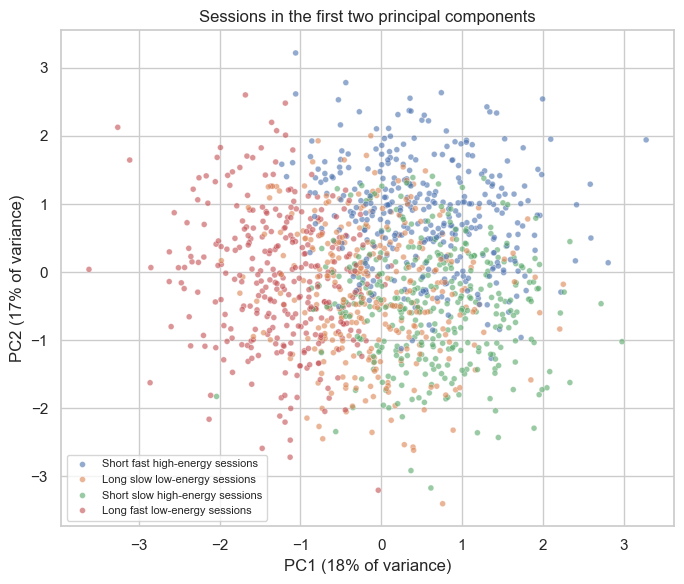

In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_

plt.figure(figsize=(7, 6))
sns.scatterplot(
    x=coords[:, 0], y=coords[:, 1],
    hue=[result.archetypes[c] for c in result.labels],
    s=18, alpha=0.6,
)
plt.title("Sessions in the first two principal components")
plt.xlabel(f"PC1 ({explained[0]:.0%} of variance)")
plt.ylabel(f"PC2 ({explained[1]:.0%} of variance)")
plt.legend(fontsize=8, loc="best")
plt.tight_layout()
plt.show()

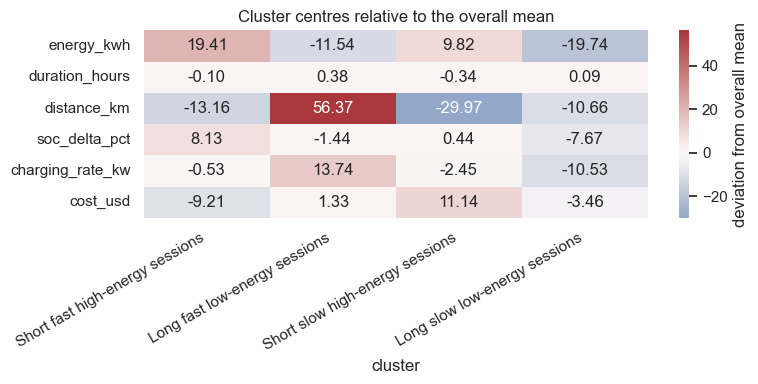

In [14]:
# Profile heatmap: cluster centres in standardised units
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(
    centred.T, annot=True, fmt=".2f", cmap="vlag", center=0,
    yticklabels=X.columns,
    xticklabels=[result.archetypes[c] for c in centred.index],
    cbar_kws={"label": "deviation from overall mean"},
)
plt.title("Cluster centres relative to the overall mean")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

**Observations**

* The first two principal components capture only a modest share of the variance, and
  the four colours are heavily intermixed — visual confirmation that the clusters are
  slices of one cloud, not islands.
* The heatmap is the useful artefact: it shows, at a glance, that each archetype is
  "high/low energy × long/short duration", which is a legitimate way to describe a
  session even without crisp separation.

## What the low silhouette means

The EDA notebook predicted this: the sessions form a single diffuse blob because every
measured quantity was sampled roughly independently. K-Means still returns four groups,
and they are internally coherent enough to describe — but the silhouette of ~0.12 says
they are **soft segments**, not natural kinds.

How to use this honestly:

* The archetypes are fine as a **descriptive lens** for the operator dashboard ("what
  share of sessions are long, low-energy charges?") and as a coarse context feature for
  the recommendation engine.
* They should **not** be presented as discovered customer personas or used to make
  strong claims. The dashboard copy and the README say the separation is weak.
* On a real dataset with genuine behavioural structure, the same pipeline — same
  features, same elbow/silhouette procedure — would report a higher silhouette and
  sharper clusters.

## Persist the segmenter

`segmentation.train()` re-runs the `k` search, fits the pipeline, and saves
`session_segmenter.joblib` (the fitted `StandardScaler` → `KMeans` plus the archetype
names) and the `"segmentation"` block of `models/metrics.json`.

In [15]:
from evcharging.models.segmentation import train

seg_result, seg_search = train(df)
print("k =", seg_result.k, " silhouette =", round(seg_result.silhouette, 3))
seg_result.metrics_payload()

k = 4  silhouette = 0.115


{'k': 4,
 'n_sessions': 1320,
 'silhouette': 0.1152,
 'features': ['energy_kwh',
  'duration_hours',
  'distance_km',
  'soc_delta_pct',
  'charging_rate_kw',
  'cost_usd'],
 'archetypes': {'0': 'Short fast high-energy sessions',
  '1': 'Long fast low-energy sessions',
  '2': 'Short slow high-energy sessions',
  '3': 'Long slow low-energy sessions'},
 'cluster_sizes': {'0': 340, '1': 316, '2': 343, '3': 321}}

In [16]:
from evcharging.models.common import load_artifact

bundle = load_artifact("session_segmenter.joblib")
new_session = X.iloc[[0]]
predicted_cluster = bundle["pipeline"].predict(new_session)[0]
bundle["archetypes"][predicted_cluster]

'Short fast high-energy sessions'

## Summary / Key Takeaways

* With one session per user, segmentation is done at the **session** level on six
  behavioural features (energy, duration, distance, SOC swing, rate, cost).
* The elbow is gentle and the silhouette is flat at ~0.12 for all `k`; `choose_k` falls
  back to `k = 4`.
* The four archetypes separate on energy and duration and are close to equal in size.
  They are usable as a descriptive lens, not as hard personas.
* `session_segmenter.joblib` stores the scaler, the K-Means model and the derived
  archetype names. Notebook `06_anomaly_detection.ipynb` is next.